# Tutorial: Complex Tensor Networks by Hand with TensorKrowch

Audience:
- Readers of this repository who want a TensorKrowch notebook that mirrors the TensorNetwork introduction without jumping into the mini-Qiskit abstraction.

Prerequisites:
- Basic PyTorch tensors.
- A rough idea of what a tensor network edge represents.

Learning goals:
- Build nontrivial tensor networks manually with `tk.Node` and `tk.connect`.
- Render the same network in both `2D` and `3D` with `tensor_network_viz`.
- Contract three different topologies with readable TensorKrowch-native steps.
- See where TensorKrowch preserves axis names cleanly and where explicit reordering helps readability.

The tensors in this notebook are deterministic normalized PyTorch tensors. The point is not domain semantics; the point is to learn how topology, visualization, and explicit contractions interact in TensorKrowch.


## Outline

1. Shared setup and plotting helpers.
2. A layered feed-forward style network.
3. A loopy lattice patch with one open probe leg.
4. A hierarchical tree network.
5. A closing comparison of the three topologies and the TensorKrowch-specific workflow.


## Shared Setup

The helper cell below does five things:

- creates deterministic normalized tensors from integer seeds,
- builds `tk.Node` objects on a consistent device and dtype,
- renders an explicit list of nodes in both `2D` and `3D`,
- prints compact shape summaries after contraction,
- reorders or renames axes after contractions when TensorKrowch does not preserve the pedagogical order automatically.

The plotting helper is careful about headless verification: if the backend is non-interactive, it closes the figures instead of calling `plt.show()`.


In [1]:
from __future__ import annotations

import torch
import tensorkrowch as tk
from tensor_network_viz import PlotConfig, show_tensor_network

%matplotlib widget

torch.set_printoptions(precision=4, sci_mode=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
print(f"TensorKrowch device: {DEVICE}")


def normalized_tensor(shape, seed: int):
    """Create a deterministic random tensor with unit Frobenius norm."""
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)
    data = torch.randn(*shape, generator=generator, dtype=DTYPE)
    norm = torch.linalg.vector_norm(data.reshape(-1))
    tensor = data / norm if norm else data
    return tensor.to(DEVICE)


def make_node(shape, seed: int, *, name: str, axes_names):
    tensor = normalized_tensor(shape, seed)
    return tk.Node(
        shape=tensor.shape,
        axes_names=list(axes_names),
        name=name,
        tensor=tensor,
    )


def rename_axes(node: tk.Node, axes_names, *, name: str | None = None):
    if len(node.axes) != len(axes_names):
        raise ValueError(
            f"Axis-name count mismatch for {node.name}: expected {len(node.axes)} names, got {len(axes_names)}."
        )
    for axis, axis_name in zip(node.axes, axes_names):
        axis.name = axis_name
    if name is not None:
        node.name = name
    return node


def reorder_axes(node: tk.Node, axes_names, *, name: str | None = None):
    reordered = tk.permute(node, tuple(axes_names))
    return rename_axes(reordered, tuple(axes_names), name=name)


def render_2d_3d(
    nodes,
    title: str,
    *,
    figsize_2d=(8, 5),
    layout_iterations=300,
):
    """Render the same explicit node list in two different views."""
    nodes = sorted(nodes, key=lambda node: node.name)

    fig2d, ax2d = show_tensor_network(
        nodes,
        engine="tensorkrowch",
        view="2d",
        config=PlotConfig(figsize=figsize_2d, layout_iterations=layout_iterations)
    )
    ax2d.set_title(f"{title} (2D)")


    return nodes


def shape_report(label: str, node_or_tensor):
    tensor = node_or_tensor.tensor if hasattr(node_or_tensor, "tensor") else node_or_tensor
    print(f"{label}: shape={tuple(tensor.shape)}")


def dangling_edge_count(nodes):
    return sum(edge.is_dangling() for node in nodes for edge in node.edges)


TensorKrowch device: cpu


## Family 1 - Layered Feed-Forward Network

This topology is acyclic: information moves from inputs to hidden tensors to a readout tensor, with no loops. It is a good first complex example because the contraction order is easy to reason about.

Structurally, the network has:

- three input vectors,
- two intermediate tensors,
- one readout tensor with a small output leg called `class`.

The main idea is that layered networks are visually richer than a single matrix multiplication, but they still contract naturally in stages.


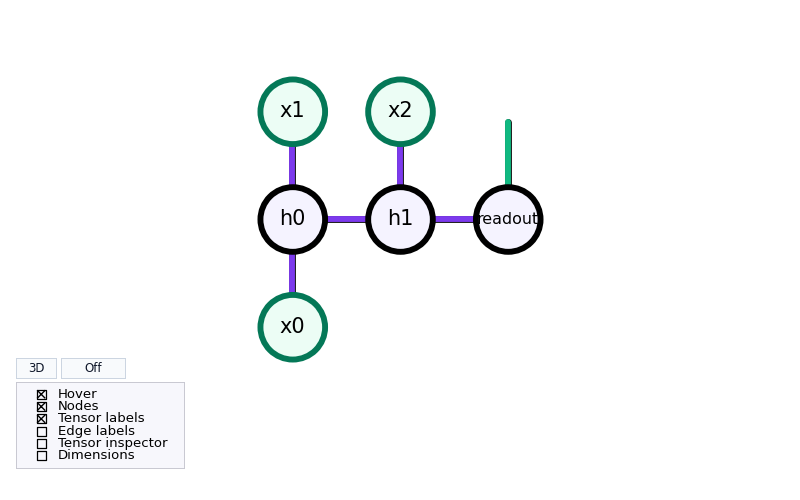

Layered node count: 6
Dangling edges: 1


In [2]:
def build_layered_network():
    """Build a layered feed-forward tensor network."""
    x0 = make_node((3,), 10, name="x0", axes_names=("f0",))
    x1 = make_node((3,), 11, name="x1", axes_names=("f1",))
    x2 = make_node((3,), 12, name="x2", axes_names=("f2",))

    h0 = make_node((3, 3, 4), 20, name="h0", axes_names=("f0", "f1", "h0"))
    h1 = make_node((3, 4, 4), 21, name="h1", axes_names=("f2", "h0_in", "h1"))
    readout = make_node((4, 2), 22, name="readout", axes_names=("h1_in", "class"))

    tk.connect(x0["f0"], h0["f0"])
    tk.connect(x1["f1"], h0["f1"])
    tk.connect(h0["h0"], h1["h0_in"])
    tk.connect(x2["f2"], h1["f2"])
    tk.connect(h1["h1"], readout["h1_in"])

    return {
        "x0": x0,
        "x1": x1,
        "x2": x2,
        "h0": h0,
        "h1": h1,
        "readout": readout,
    }


layered = build_layered_network()
layered_nodes = render_2d_3d(list(layered.values()), "Layered feed-forward network")
print("Layered node count:", len(layered_nodes))
print("Dangling edges:", dangling_edge_count(layered_nodes))


In [3]:
x0 = layered["x0"]
x1 = layered["x1"]
x2 = layered["x2"]
h0 = layered["h0"]
h1 = layered["h1"]
readout = layered["readout"]

layer01 = reorder_axes(tk.contract_between(x0, h0), ("f1", "h0"), name="x0_h0")
layer02 = rename_axes(tk.contract_between(x1, layer01), ("h0",), name="hidden0")
layer03 = reorder_axes(tk.contract_between(layer02, h1), ("f2", "h1"), name="hidden1")
layer04 = rename_axes(tk.contract_between(x2, layer03), ("h1",), name="pre_readout")
layer05 = rename_axes(tk.contract_between(layer04, readout), ("class",), name="output")

shape_report("Layered output", layer05)
print(layer05.tensor)


Layered output: shape=(2,)
tensor([-0.0015, -0.0042], dtype=torch.float64)


## Family 2 - Loopy Lattice Patch

This example is closer to a small PEPS-like patch. Unlike the layered network, it contains cycles: every square in the patch introduces a loop in the connectivity graph.

To make the final contraction readable, most boundary legs are closed with rank-1 probe tensors. One boundary leg, the top edge of the middle site, is left open so that the full patch contracts to a small vector instead of to a giant high-rank tensor.

This is the visually richest topology in the notebook and the one where `2D` and `3D` views help the most.


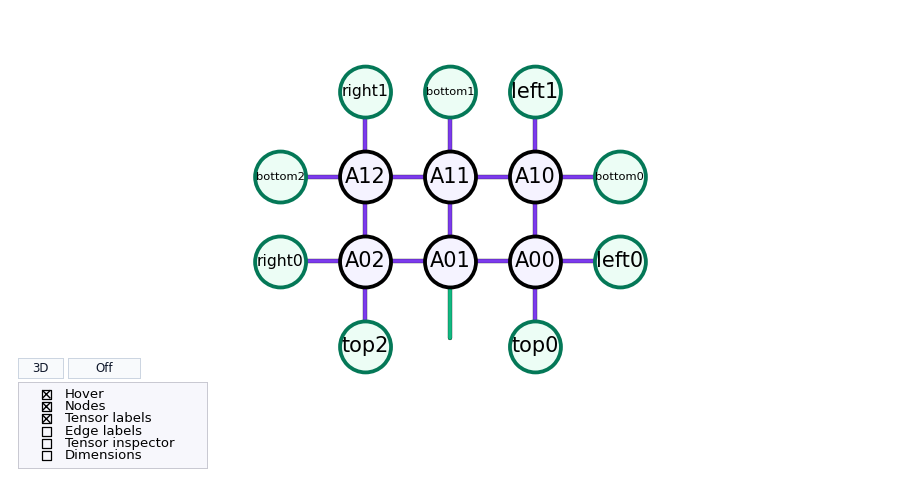

Lattice node count: 15
Remaining open leg: A01[up] <-> None


In [4]:
def build_lattice_patch():
    sites = {}
    for row in range(2):
        for col in range(3):
            sites[row, col] = make_node(
                (2, 2, 2, 2),
                100 + 10 * row + col,
                name=f"A{row}{col}",
                axes_names=("up", "right", "down", "left"),
            )

    for row in range(2):
        for col in range(3):
            if col < 2:
                tk.connect(sites[row, col]["right"], sites[row, col + 1]["left"])
            if row < 1:
                tk.connect(sites[row, col]["down"], sites[row + 1, col]["up"])

    boundary = {}

    for col in range(3):
        if col != 1:
            probe = make_node((2,), 200 + col, name=f"top{col}", axes_names=(f"top{col}",))
            tk.connect(probe[f"top{col}"], sites[0, col]["up"])
            boundary[f"top{col}"] = probe

    for col in range(3):
        probe = make_node((2,), 210 + col, name=f"bottom{col}", axes_names=(f"bottom{col}",))
        tk.connect(probe[f"bottom{col}"], sites[1, col]["down"])
        boundary[f"bottom{col}"] = probe

    for row in range(2):
        probe = make_node((2,), 220 + row, name=f"left{row}", axes_names=(f"left{row}",))
        tk.connect(probe[f"left{row}"], sites[row, 0]["left"])
        boundary[f"left{row}"] = probe

    for row in range(2):
        probe = make_node((2,), 230 + row, name=f"right{row}", axes_names=(f"right{row}",))
        tk.connect(probe[f"right{row}"], sites[row, 2]["right"])
        boundary[f"right{row}"] = probe

    all_nodes = list(sites.values()) + list(boundary.values())
    return sites, boundary, all_nodes


lattice_sites, lattice_boundary, lattice_nodes = build_lattice_patch()
render_2d_3d(
    lattice_nodes,
    "Loopy lattice patch",
    figsize_2d=(9, 5),
    layout_iterations=350,
)
print("Lattice node count:", len(lattice_nodes))
print("Remaining open leg:", lattice_sites[0, 1]["up"])


In [5]:
# The labels mirror the geometry of the patch: repeated letters are contracted,
# and the single surviving output label corresponds to the top edge of A01.
lattice_result = rename_axes(
    tk.einsum(
        "abcd,efgb,hijf,cklm,gnok,jpqn,a,h,l,o,q,d,m,i,p->e",
        lattice_sites[0, 0],
        lattice_sites[0, 1],
        lattice_sites[0, 2],
        lattice_sites[1, 0],
        lattice_sites[1, 1],
        lattice_sites[1, 2],
        lattice_boundary["top0"],
        lattice_boundary["top2"],
        lattice_boundary["bottom0"],
        lattice_boundary["bottom1"],
        lattice_boundary["bottom2"],
        lattice_boundary["left0"],
        lattice_boundary["left1"],
        lattice_boundary["right0"],
        lattice_boundary["right1"],
    ),
    ("up",),
    name="lattice_result",
)

shape_report("Lattice result", lattice_result)
print(lattice_result.tensor)


Lattice result: shape=(2,)
tensor([ 0.0005, -0.0001], dtype=torch.float64)


## Family 3 - Hierarchical Tree Network

Trees have depth, but no loops. That makes them a good contrast with the lattice patch.

This example starts with eight leaf vectors. They are merged upward by two layers of rank-3 tensors and then reduced at the root. The contraction is naturally bottom-up: first combine leaves into small summaries, then combine those summaries again, and only at the end hit the root.

In other words, the topology is not sequential like the layered network and not cyclic like the lattice; it is reduction-oriented.


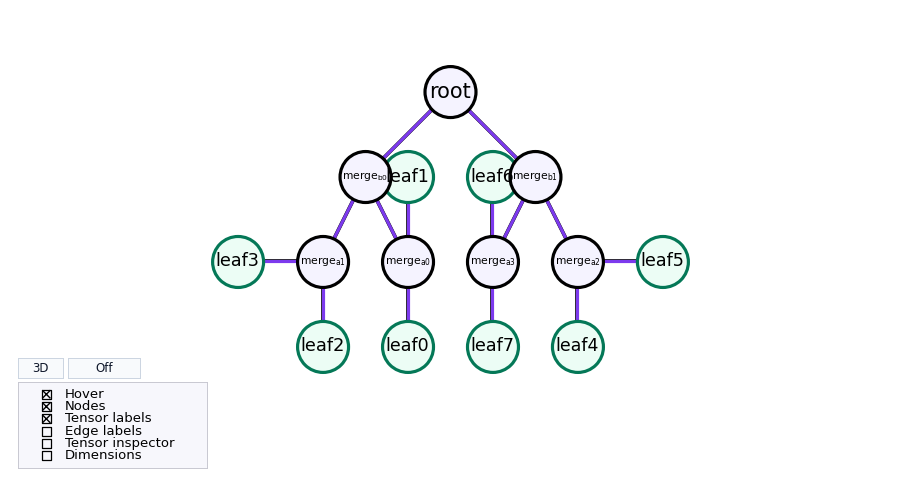

Tree node count: 15
Dangling edges at the leaves: 0


In [6]:
def build_tree_network():
    leaves = [
        make_node((3,), 300 + i, name=f"leaf{i}", axes_names=(f"x{i}",))
        for i in range(8)
    ]

    merge_a = [
        make_node((3, 3, 4), 400 + i, name=f"merge_a{i}", axes_names=(f"l{i}", f"r{i}", f"p{i}"))
        for i in range(4)
    ]

    merge_b = [
        make_node((4, 4, 5), 500 + i, name=f"merge_b{i}", axes_names=(f"l2{i}", f"r2{i}", f"p2{i}"))
        for i in range(2)
    ]

    root = make_node((5, 5), 600, name="root", axes_names=("left_root", "right_root"))

    for i in range(4):
        tk.connect(leaves[2 * i][f"x{2 * i}"], merge_a[i][f"l{i}"])
        tk.connect(leaves[2 * i + 1][f"x{2 * i + 1}"], merge_a[i][f"r{i}"])

    for i in range(2):
        tk.connect(merge_a[2 * i][f"p{2 * i}"], merge_b[i][f"l2{i}"])
        tk.connect(merge_a[2 * i + 1][f"p{2 * i + 1}"], merge_b[i][f"r2{i}"])

    tk.connect(merge_b[0]["p20"], root["left_root"])
    tk.connect(merge_b[1]["p21"], root["right_root"])

    return leaves, merge_a, merge_b, root


tree_leaves, tree_merge_a, tree_merge_b, tree_root = build_tree_network()
tree_nodes = render_2d_3d(
    [*tree_leaves, *tree_merge_a, *tree_merge_b, tree_root],
    "Hierarchical tree network",
    figsize_2d=(9, 5),
    layout_iterations=350,
)
print("Tree node count:", len(tree_nodes))
print("Dangling edges at the leaves:", sum(edge.is_dangling() for node in tree_leaves for edge in node.edges))


In [7]:
level1 = []
for i in range(4):
    left = reorder_axes(
        tk.contract_between(tree_leaves[2 * i], tree_merge_a[i]),
        (f"r{i}", f"p{i}"),
        name=f"leaf_merge_{i}_left",
    )
    merged = rename_axes(
        tk.contract_between(tree_leaves[2 * i + 1], left),
        (f"p{i}",),
        name=f"level1_{i}",
    )
    level1.append(merged)

level2 = []
for i in range(2):
    left = reorder_axes(
        tk.contract_between(level1[2 * i], tree_merge_b[i]),
        (f"r2{i}", f"p2{i}"),
        name=f"level2_left_{i}",
    )
    merged = rename_axes(
        tk.contract_between(level1[2 * i + 1], left),
        (f"p2{i}",),
        name=f"level2_{i}",
    )
    level2.append(merged)

top = rename_axes(tk.contract_between(level2[0], tree_root), ("right_root",), name="top")
tree_result = rename_axes(tk.contract_between(level2[1], top), (), name="tree_result")

shape_report("Tree result", tree_result)
print(tree_result.tensor)


Tree result: shape=()
tensor(-0.0000, dtype=torch.float64)


## Topology Comparison

- **Layered feed-forward network:** acyclic, staged, and easy to contract in the same order in which it is drawn.
- **Loopy lattice patch:** locally regular, globally more tangled, and visually richer because cycles create spatial structure.
- **Hierarchical tree network:** loop-free like the layered case, but not sequential; the natural contraction order is bottom-up.

The TensorKrowch-specific difference from the TensorNetwork version is small but important: here we pass explicit node lists to the visualizer, wire edges with `tk.connect`, use `tk.contract_between` for staged reductions, and switch to an explicit `tk.einsum(...)` expression for the loopy patch instead of relying on a greedy contractor.

Common pitfall: after some contractions, the resulting axes may be correct mathematically but appear in an order that is harder to read. The `reorder_axes(...)` helper keeps the tutorial outputs aligned with the diagram.

Easy extension: move the notebook to CUDA when available, swap the boundary probes, or leave more lattice legs open and inspect how quickly the output rank grows.
